REGIONES CONECTIVIDAD Y FRONTERAS

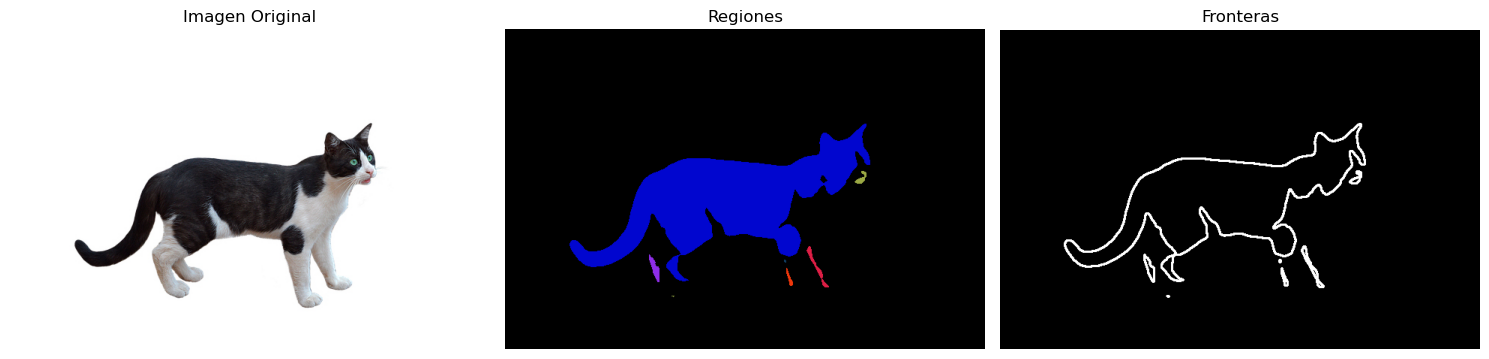

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\a jpeg\gato2.jpg")
img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
img_blur=cv2.GaussianBlur(img_gray,(7,7),0)
_,binarizada=cv2.threshold(img_blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#regiones
cant,region=cv2.connectedComponents(binarizada)
colores = np.random.randint(0, 255, size=(cant, 3), dtype=np.uint8)

colores[0]=[0,0,0]
color_region=colores[region]
#fronteras
contorno,_=cv2.findContours(binarizada,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
lineas=cv2.drawContours(np.zeros_like(img_gray),contorno,-1,255,2)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Regiones")
plt.imshow(color_region)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Fronteras")
plt.imshow(lineas, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

Distancias

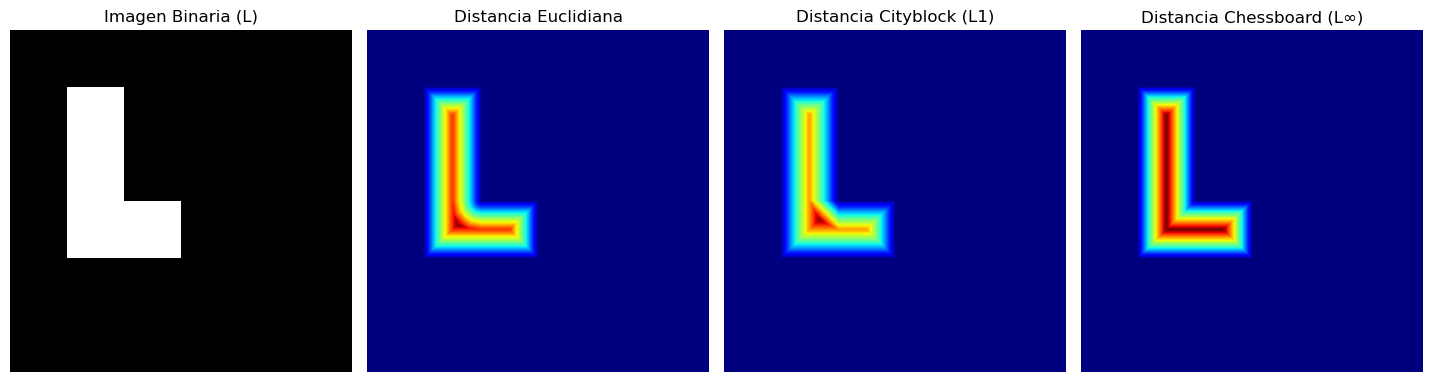

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = np.zeros((300, 300), dtype=np.uint8)
imagen[50:150, 50:100] = 1
imagen[150:200, 50:150] = 1

def distancia(img_binarizada):
    invertir = 1 - img_binarizada

    # Euclidiana
    dist_eucli = cv2.distanceTransform(img_binarizada, cv2.DIST_L2, 5)
    # Cityblock (L1)
    dist_city = cv2.distanceTransform(img_binarizada, cv2.DIST_L1, 3)
    # Chessboard (L∞)
    dist_ches = cv2.distanceTransform(img_binarizada, cv2.DIST_C, 3)

    return dist_eucli, dist_city, dist_ches
def normalizar(dist):
    return cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
eucli, city, ches = distancia(imagen)
norm_enclu = normalizar(eucli)
norm_city = normalizar(city)
norm_ches = normalizar(ches)
plt.figure(figsize=(18, 5))
plt.subplot(1, 5, 1)
plt.title("Imagen Binaria (L)")
plt.imshow(imagen, cmap='gray')
plt.axis("off")
plt.subplot(1, 5, 2)
plt.title("Distancia Euclidiana")
plt.imshow(norm_enclu, cmap='jet')
plt.axis("off")
plt.subplot(1, 5, 3)
plt.title("Distancia Cityblock (L1)")
plt.imshow(norm_city, cmap='jet')
plt.axis("off")
plt.subplot(1, 5, 4)
plt.title("Distancia Chessboard (L∞)")
plt.imshow(norm_ches, cmap='jet')
plt.axis("off")

# Mostrar todo junto
plt.tight_layout()
plt.show()



Contadores

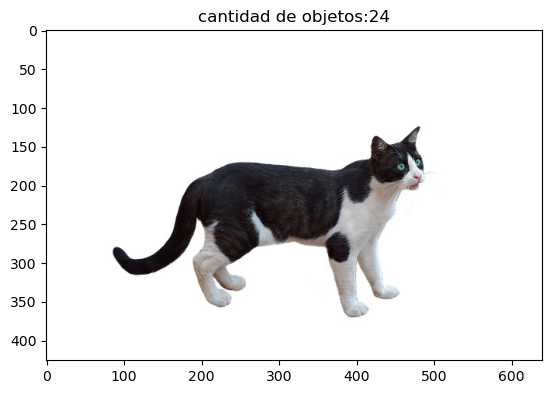

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(image):
    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    etiquetar = measure.label(binary, connectivity=2)
    num = np.max(etiquetar)
    return num

imagen=cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\a jpeg\gato2.jpg")
contarr=contar(imagen)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f"cantidad de objetos:{contarr}")
plt.show()

Tarea mostrar la region y bordes de los conteos

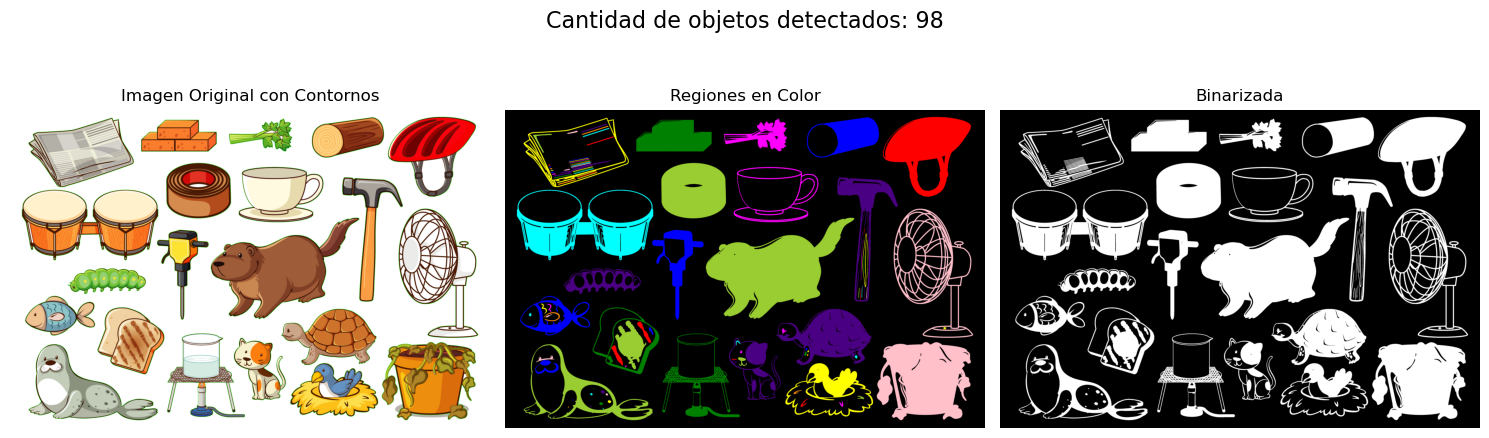

Total de objetos detectados: 98


In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, color

def mostrar_regiones_y_contar_objetos(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (7, 7), 0)
    _, binarizada = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    etiquetas = measure.label(binarizada, connectivity=2)
    cantidad_objetos = np.max(etiquetas)
    imagen_coloreada = color.label2rgb(etiquetas, bg_label=0, bg_color=(0, 0, 0), kind='overlay')
    contornos, _ = cv2.findContours(binarizada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    imagen_con_contornos = imagen.copy()
    cv2.drawContours(imagen_con_contornos, contornos, -1, (0, 255, 0), 2)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Imagen Original con Contornos")
    plt.imshow(cv2.cvtColor(imagen_con_contornos, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Regiones en Color")
    plt.imshow(imagen_coloreada)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Binarizada")
    plt.imshow(binarizada, cmap='gray')
    plt.axis("off")

    plt.suptitle(f"Cantidad de objetos detectados: {cantidad_objetos}", fontsize=16)
    plt.tight_layout()
    plt.show()

    return cantidad_objetos


imagen = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos.jpg")
objetos = mostrar_regiones_y_contar_objetos(imagen)
print(f"Total de objetos detectados: {objetos}")


etiquetado normal

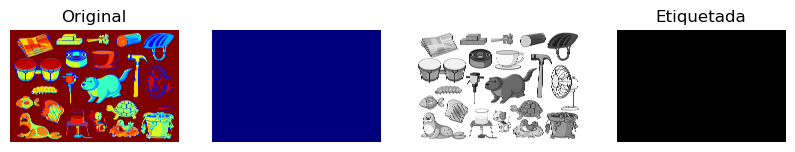

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
def etiquetar(img):
    #tiene que estar umbralizado
    _,imgU=cv2.threshold(img,128,255,cv2.THRESH_BINARY)
    #encontrar los contornos
    contorno,_=cv2.findContours(imgU,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    
    img_etiq=np.zeros_like(img,dtype=np.uint8)
    for i ,contornos in enumerate(contorno):
        cv2.drawContours(img_etiq,[contornos],-1,(i+1),-1)
    return img_etiq
imagen = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos.jpg",0)

img_etiquetada = etiquetar(imagen)

plt.figure(figsize=(10, 5))

plt.subplot(2, 4, 1)
plt.title("Original")
plt.imshow(imagen, cmap='jet')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_etiquetada, cmap='jet') 
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(imagen, cmap='gray') 
plt.axis('off')

plt.subplot(2, 4, 4)
plt.title("Etiquetada")
plt.imshow(img_etiquetada, cmap='gray') 
plt.axis('off')
plt.show()

etiquetado con measure

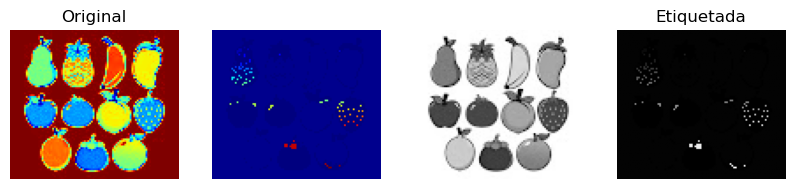

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
img_gray=cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\frutas.jpg",0)
_,imgbin=cv2.threshold(img_gray,128,255,cv2.THRESH_BINARY)
img_etiq=measure.label(imgbin,connectivity=1)
plt.figure(figsize=(10, 5))

plt.subplot(2, 4, 1)
plt.title("Original")
plt.imshow(img_gray, cmap='jet')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_etiq, cmap='jet') 
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(img_gray, cmap='gray') 
plt.axis('off')

plt.subplot(2, 4, 4)
plt.title("Etiquetada")
plt.imshow(img_etiq, cmap='gray') 
plt.axis('off')
plt.show()

conteo normal

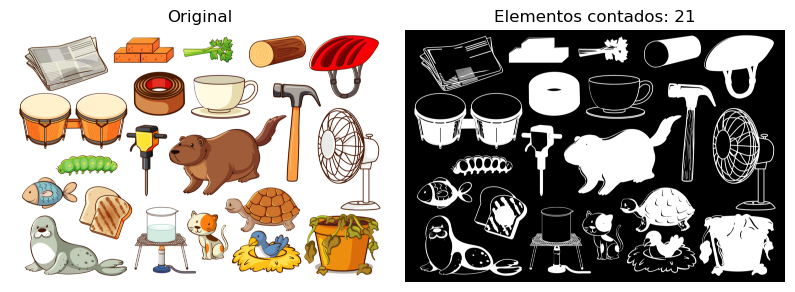

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conteo(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, imgbin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contornos, _ = cv2.findContours(imgbin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = len(contornos)
    return count, imgbin

imagen = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos.jpg")

total, binarizada = conteo(imagen)


plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')



plt.subplot(1, 3, 2)
plt.title(f"Elementos contados: {total}")
plt.imshow(cv2.cvtColor(binarizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


conteo measure

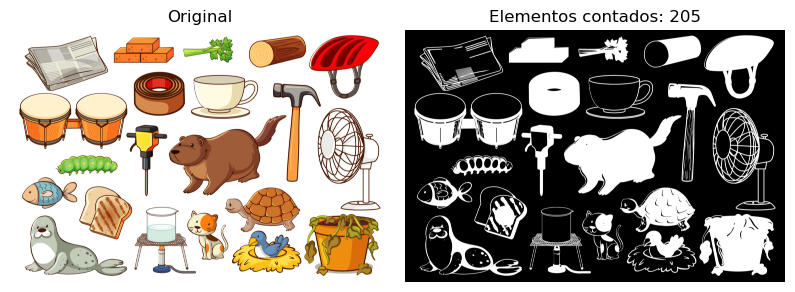

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conteo2(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, imgbin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    contornos= measure.label(imgbin, connectivity=2)
    count = np.max(contornos)
    return count, imgbin

imagen = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos.jpg")

total, binarizada = conteo2(imagen)


plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')



plt.subplot(1, 3, 2)
plt.title(f"Elementos contados: {total}")
plt.imshow(cv2.cvtColor(binarizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()
